# 06. Anomaly Detection

**Goal:** Flag unusual pollution events using model residuals and statistical thresholds.

### What is an anomaly in this context?
A day where NO2 is **significantly higher or lower** than what our model predicted. This could indicate:
- Pollution spikes (traffic incidents, industrial events or bonfires)
- Unusually clean days (lockdowns, strong winds or rain washout)
- Sensor malfunctions

### Methods
1. **Z-score on residuals**. Flag days where the residual exceeds ±2 or ±3 standard deviations
2. **GARCH-based** using dynamic volatility to set adaptive thresholds (tighter on calm days, wider on volatile days)
3. **Rolling statistics** to flag days where NO2 deviates from its rolling mean

In [1]:
import sqlite3
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

SAVED_DIR = "../models/saved"

print("All imports loaded ✓")

All imports loaded ✓


## 1. Load Data & ARIMA Residuals

In [2]:
DB_PATH = "../database/air_quality.db"
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM clean_daily_my1", conn, parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)
conn.close()

no2 = df["no2"].copy()

# Load ARIMA model and get residuals for the full training period
arima_fit = pickle.load(open(os.path.join(SAVED_DIR, "arima_best_fit.pkl"), "rb"))
residuals = arima_fit.resid

print(f"NO2: {len(no2)} days")
print(f"ARIMA residuals: {len(residuals)} days")
print(f"Residual mean: {residuals.mean():.3f}, std: {residuals.std():.2f}")

NO2: 1752 days
ARIMA residuals: 1662 days
Residual mean: -0.022, std: 13.45


## 2. Method 1: Z-Score Anomaly Detection on Residuals

Flag days where the ARIMA residual exceeds a threshold:
- **±2σ** → ~5% of days flagged (moderate threshold)
- **±3σ** → ~0.3% of days flagged (strict threshold)

Anomalies detected:
  ±2σ threshold: 84 days (5.1%)
  ±3σ threshold: 13 days (0.8%)


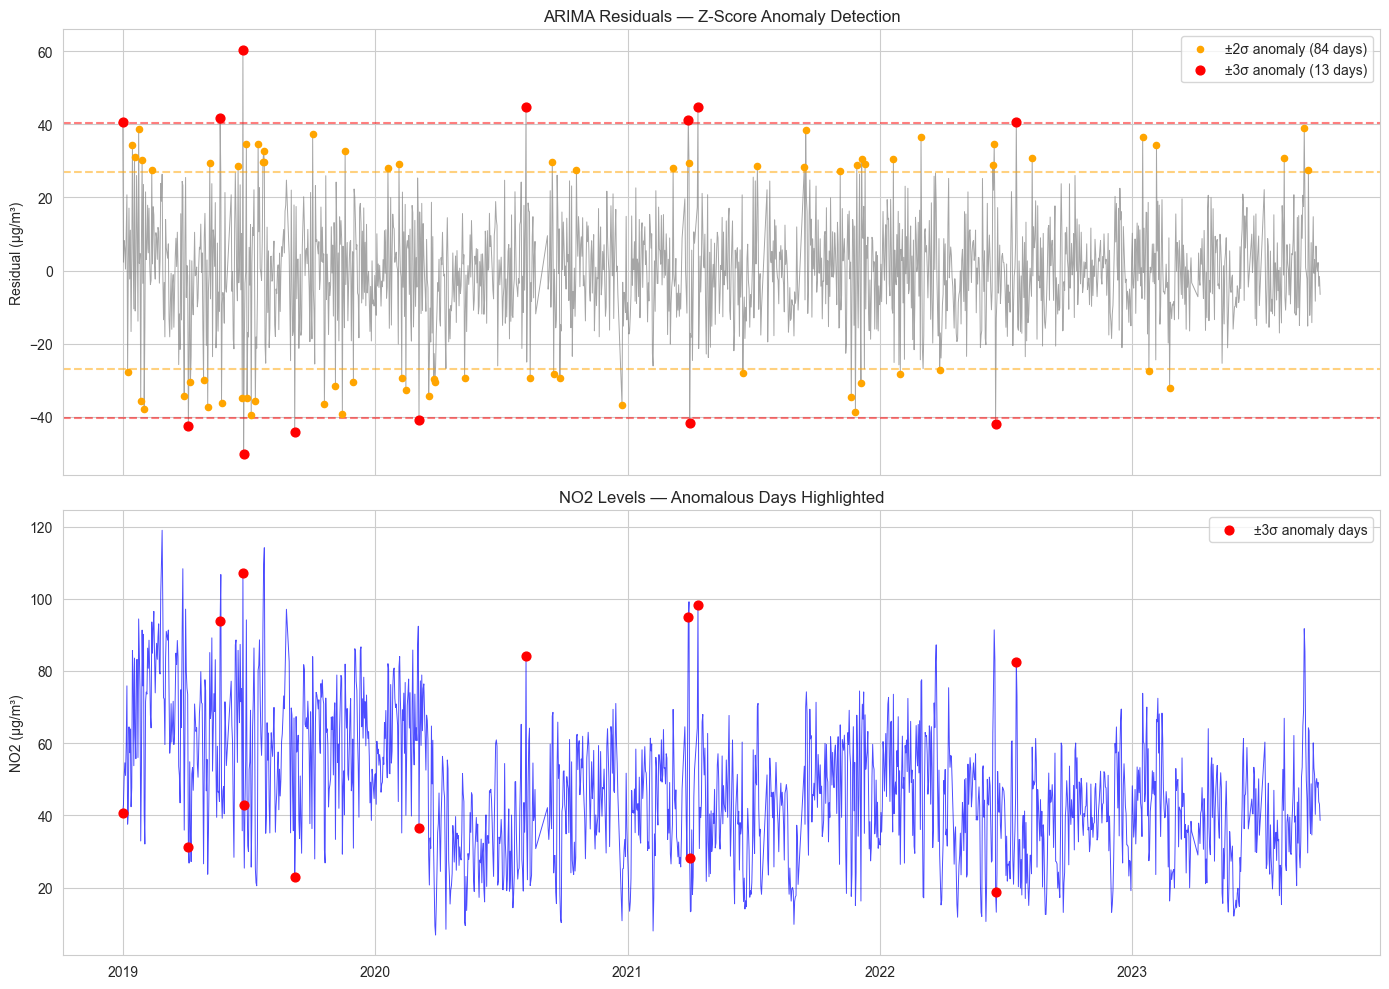

In [3]:
# Z-score anomaly detection
resid_mean = residuals.mean()
resid_std = residuals.std()
z_scores = (residuals - resid_mean) / resid_std

# Flag anomalies at different thresholds
anomalies_2sigma = np.abs(z_scores) > 2
anomalies_3sigma = np.abs(z_scores) > 3

print(f"Anomalies detected:")
print(f"  ±2σ threshold: {anomalies_2sigma.sum()} days ({anomalies_2sigma.mean()*100:.1f}%)")
print(f"  ±3σ threshold: {anomalies_3sigma.sum()} days ({anomalies_3sigma.mean()*100:.1f}%)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Residuals with anomalies highlighted
axes[0].plot(residuals.index, residuals.values, linewidth=0.7, color="gray", alpha=0.7)
axes[0].scatter(residuals.index[anomalies_2sigma], residuals.values[anomalies_2sigma],
                color="orange", s=20, label=f"±2σ anomaly ({anomalies_2sigma.sum()} days)", zorder=5)
axes[0].scatter(residuals.index[anomalies_3sigma], residuals.values[anomalies_3sigma],
                color="red", s=40, label=f"±3σ anomaly ({anomalies_3sigma.sum()} days)", zorder=6)
axes[0].axhline(2*resid_std, color="orange", linestyle="--", alpha=0.5)
axes[0].axhline(-2*resid_std, color="orange", linestyle="--", alpha=0.5)
axes[0].axhline(3*resid_std, color="red", linestyle="--", alpha=0.5)
axes[0].axhline(-3*resid_std, color="red", linestyle="--", alpha=0.5)
axes[0].set_title("ARIMA Residuals — Z-Score Anomaly Detection")
axes[0].set_ylabel("Residual (µg/m³)")
axes[0].legend()

# Original NO2 with anomalies marked
train_idx = residuals.index
axes[1].plot(no2.loc[train_idx], linewidth=0.7, color="blue", alpha=0.7)
axes[1].scatter(train_idx[anomalies_3sigma], no2.loc[train_idx][anomalies_3sigma],
                color="red", s=40, label=f"±3σ anomaly days", zorder=5)
axes[1].set_title("NO2 Levels — Anomalous Days Highlighted")
axes[1].set_ylabel("NO2 (µg/m³)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Method 2: GARCH-Based Adaptive Anomaly Detection

Instead of a fixed threshold, use GARCH's **dynamic volatility** to set adaptive bounds. A day is anomalous if the residual exceeds ±2× the GARCH-predicted volatility for that specific day.

GARCH-based anomalies:
  ±2σ_t threshold: 79 days (4.8%)
  ±3σ_t threshold: 8 days (0.5%)


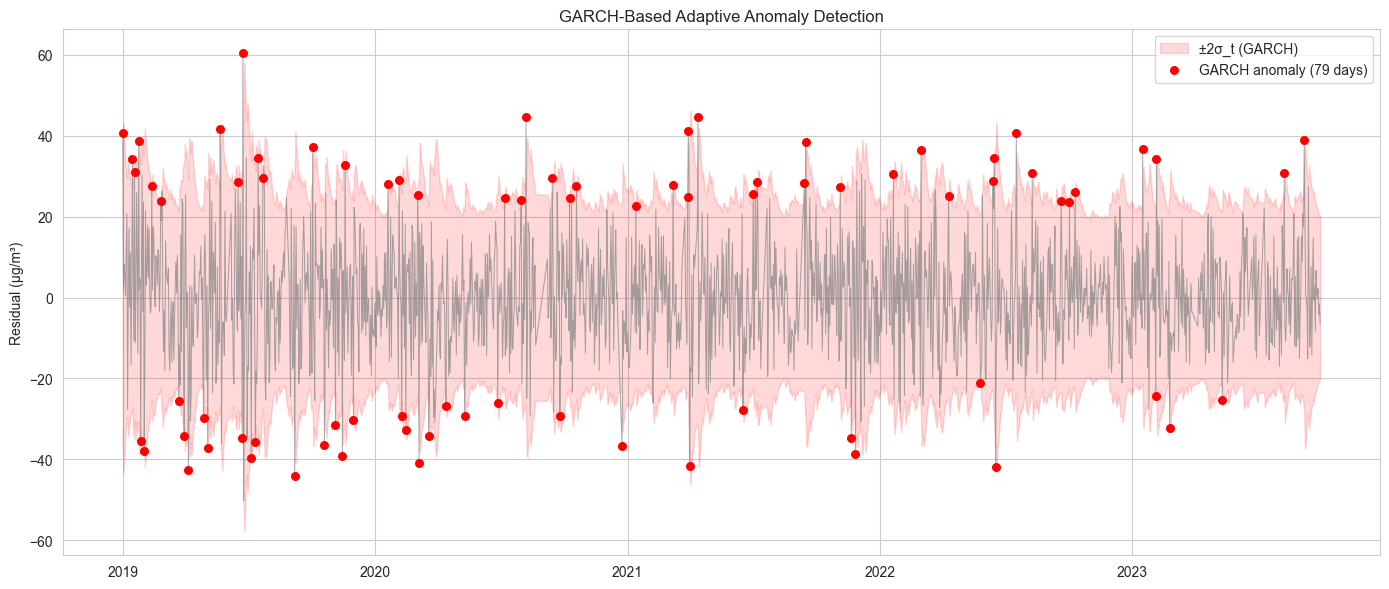

In [4]:
# Load GARCH model and get conditional volatility
garch_fit = pickle.load(open(os.path.join(SAVED_DIR, "garch_best_fit.pkl"), "rb"))
cond_vol = garch_fit.conditional_volatility / 100  # scale back

# Align lengths
n = min(len(residuals), len(cond_vol))
resid_aligned = residuals.values[-n:]
vol_aligned = cond_vol[-n:]
idx_aligned = residuals.index[-n:]

# GARCH-based anomaly: residual exceeds ±2× conditional volatility
garch_z = np.abs(resid_aligned) / vol_aligned
garch_anomalies_2 = garch_z > 2
garch_anomalies_3 = garch_z > 3

print(f"GARCH-based anomalies:")
print(f"  ±2σ_t threshold: {garch_anomalies_2.sum()} days ({garch_anomalies_2.mean()*100:.1f}%)")
print(f"  ±3σ_t threshold: {garch_anomalies_3.sum()} days ({garch_anomalies_3.mean()*100:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(idx_aligned, resid_aligned, linewidth=0.7, color="gray", alpha=0.7)
ax.fill_between(idx_aligned, -2*vol_aligned, 2*vol_aligned, alpha=0.15, color="red", label="±2σ_t (GARCH)")
ax.scatter(idx_aligned[garch_anomalies_2], resid_aligned[garch_anomalies_2],
           color="red", s=30, label=f"GARCH anomaly ({garch_anomalies_2.sum()} days)", zorder=5)
ax.set_title("GARCH-Based Adaptive Anomaly Detection")
ax.set_ylabel("Residual (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Method 3: Rolling Mean Deviation

Flag days where NO2 deviates from its **30-day rolling mean** by more than 2 standard deviations. This method does not need a model. It is purely statistical.

Rolling mean anomalies (±2σ, window=30):
  57 days (3.3%)


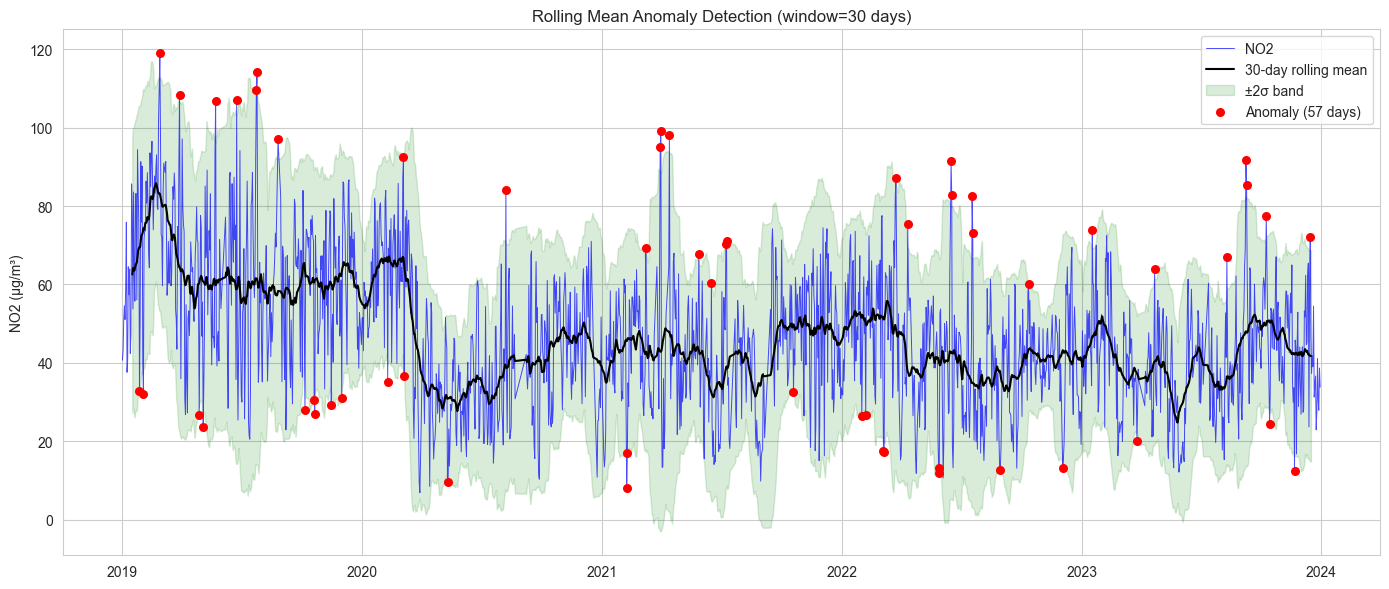

In [5]:
# Rolling mean anomaly detection
window = 30
rolling_mean = no2.rolling(window, center=True).mean()
rolling_std = no2.rolling(window, center=True).std()

upper_band = rolling_mean + 2 * rolling_std
lower_band = rolling_mean - 2 * rolling_std

rolling_anomalies = (no2 > upper_band) | (no2 < lower_band)
rolling_anomalies = rolling_anomalies.fillna(False)

print(f"Rolling mean anomalies (±2σ, window={window}):")
print(f"  {rolling_anomalies.sum()} days ({rolling_anomalies.mean()*100:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(no2, linewidth=0.7, color="blue", alpha=0.7, label="NO2")
ax.plot(rolling_mean, color="black", linewidth=1.5, label=f"{window}-day rolling mean")
ax.fill_between(no2.index, lower_band, upper_band, alpha=0.15, color="green", label="±2σ band")
ax.scatter(no2.index[rolling_anomalies], no2[rolling_anomalies],
           color="red", s=30, label=f"Anomaly ({rolling_anomalies.sum()} days)", zorder=5)
ax.set_title(f"Rolling Mean Anomaly Detection (window={window} days)")
ax.set_ylabel("NO2 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Compare All Three Methods

Method Comparison:
  Z-score (±2σ):     84 days
  GARCH (±2σ_t):     79 days
  Rolling (±2σ):     53 days
  Flagged by ≥2:     66 days
  Flagged by all 3:  19 days


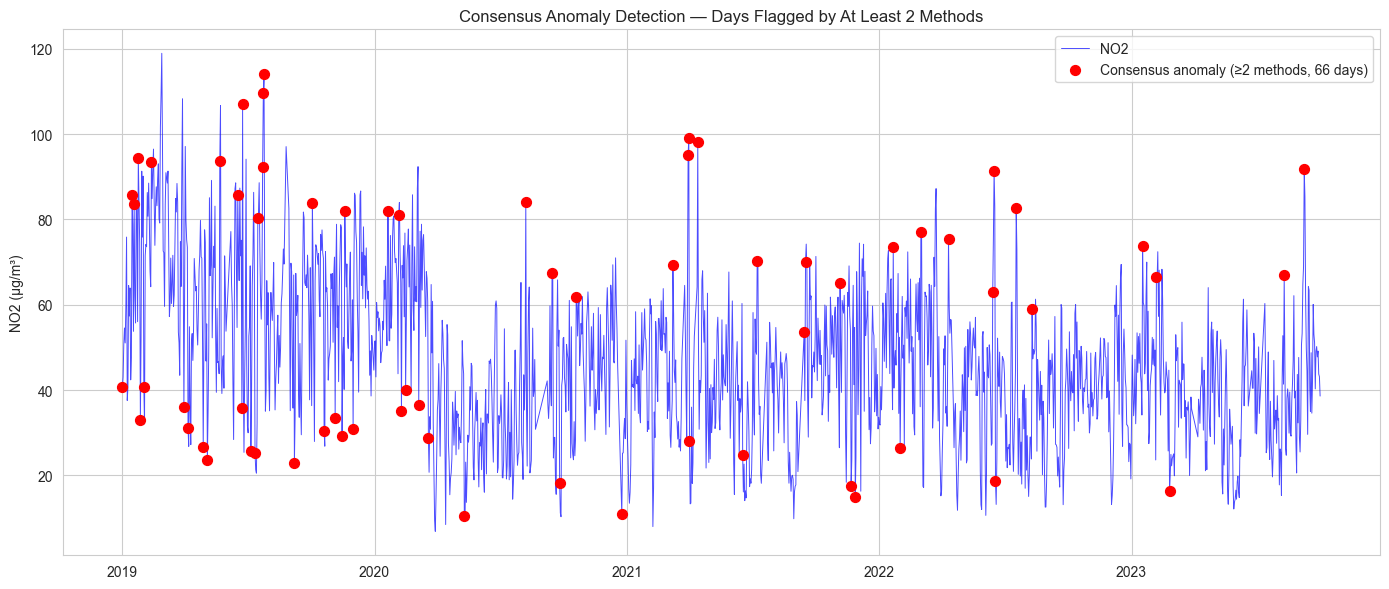

In [6]:
# Build comparison dataframe
comparison = pd.DataFrame(index=idx_aligned)
comparison["no2"] = no2.loc[idx_aligned].values
comparison["residual"] = resid_aligned
comparison["z_score_anomaly"] = anomalies_2sigma[-n:]
comparison["garch_anomaly"] = garch_anomalies_2
comparison["rolling_anomaly"] = rolling_anomalies.loc[idx_aligned].values

# Count agreement
comparison["all_three"] = comparison["z_score_anomaly"] & comparison["garch_anomaly"] & comparison["rolling_anomaly"]
comparison["at_least_two"] = (comparison[["z_score_anomaly", "garch_anomaly", "rolling_anomaly"]].sum(axis=1) >= 2)

print("Method Comparison:")
print(f"  Z-score (±2σ):     {comparison['z_score_anomaly'].sum()} days")
print(f"  GARCH (±2σ_t):     {comparison['garch_anomaly'].sum()} days")
print(f"  Rolling (±2σ):     {comparison['rolling_anomaly'].sum()} days")
print(f"  Flagged by ≥2:     {comparison['at_least_two'].sum()} days")
print(f"  Flagged by all 3:  {comparison['all_three'].sum()} days")

# Plot: consensus anomalies on NO2
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(no2.loc[idx_aligned], linewidth=0.7, color="blue", alpha=0.7, label="NO2")
ax.scatter(comparison.index[comparison["at_least_two"]], 
           comparison["no2"][comparison["at_least_two"]],
           color="red", s=50, label=f"Consensus anomaly (≥2 methods, {comparison['at_least_two'].sum()} days)", zorder=5)
ax.set_title("Consensus Anomaly Detection — Days Flagged by At Least 2 Methods")
ax.set_ylabel("NO2 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Investigate Top Anomalies: What Happened on Those Days?

In [7]:
# Top anomalies by absolute residual
anomaly_days = comparison[comparison["at_least_two"]].copy()
anomaly_days["abs_residual"] = np.abs(anomaly_days["residual"])
anomaly_days = anomaly_days.sort_values("abs_residual", ascending=False)

# Add weather context
weather_cols = ["temperature", "humidity", "windspeed"]
for col in weather_cols:
    anomaly_days[col] = df.loc[anomaly_days.index, col]

anomaly_days["day_of_week"] = anomaly_days.index.day_name()

print(f"Top 15 Anomalous Days (by residual magnitude):\n")
display(anomaly_days[["no2", "residual", "day_of_week", "temperature", "humidity", "windspeed",
                       "z_score_anomaly", "garch_anomaly", "rolling_anomaly"]].head(15))

# Day of week distribution of anomalies
print(f"\nAnomaly distribution by day of week:")
print(anomaly_days["day_of_week"].value_counts())

Top 15 Anomalous Days (by residual magnitude):



,no2,residual,day_of_week,temperature,humidity,windspeed,z_score_anomaly,garch_anomaly,rolling_anomaly
timestamp,,,,,,,,,
2019-06-24,107.020000,60.403118,Monday,20.412500,79.166667,9.250000,True,True,True
2021-04-13,98.170833,44.769489,Tuesday,5.029167,72.500000,8.350000,True,True,True
2020-08-07,84.095833,44.630572,Friday,24.583333,58.041667,6.470833,True,True,True
2019-09-07,22.875000,-44.194828,Saturday,13.645833,68.125000,12.883333,True,True,False
2019-04-06,31.108333,-42.567177,Saturday,8.166667,83.083333,17.108333,True,True,False
2022-06-18,18.666667,-41.793543,Saturday,18.887500,74.916667,14.862500,True,True,False
2021-04-01,28.079167,-41.651806,Thursday,10.245833,75.083333,18.362500,True,True,False
2019-05-22,93.829167,41.648754,Wednesday,14.070833,59.208333,8.650000,True,True,False
2021-03-30,95.041667,41.127057,Tuesday,11.700000,69.708333,7.833333,True,True,True



Anomaly distribution by day of week:
day_of_week
Tuesday      12
Thursday     12
Monday       10
Friday        9
Sunday        9
Saturday      8
Wednesday     6
Name: count, dtype: int64


## 7. Anomaly Timeline: Yearly Breakdown

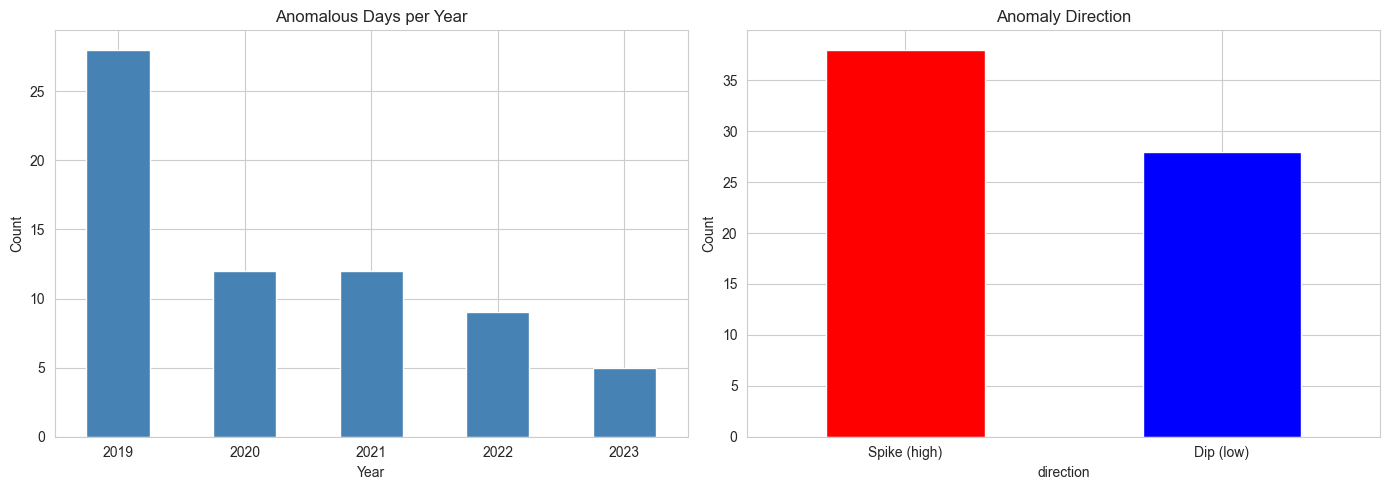


Total consensus anomalies: 66
  Spikes (NO2 higher than expected): 38
  Dips (NO2 lower than expected):    28


In [8]:
# Anomalies by year
anomaly_days["year"] = anomaly_days.index.year
yearly_counts = anomaly_days["year"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart by year
yearly_counts.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Anomalous Days per Year")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Year")
plt.sca(axes[0])
plt.xticks(rotation=0)

# Positive (spike) vs negative (dip) anomalies
anomaly_days["direction"] = np.where(anomaly_days["residual"] > 0, "Spike (high)", "Dip (low)")
direction_counts = anomaly_days["direction"].value_counts()
direction_counts.plot(kind="bar", ax=axes[1], color=["red", "blue"])
axes[1].set_title("Anomaly Direction")
axes[1].set_ylabel("Count")
plt.sca(axes[1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(f"\nTotal consensus anomalies: {len(anomaly_days)}")
print(f"  Spikes (NO2 higher than expected): {(anomaly_days['direction'] == 'Spike (high)').sum()}")
print(f"  Dips (NO2 lower than expected):    {(anomaly_days['direction'] == 'Dip (low)').sum()}")

## 8. Key Takeaways

In [9]:
print("="*60)
print("KEY TAKEAWAYS (based on actual results)")
print("="*60)
print(f"• 3 anomaly detection methods applied: Z-score, GARCH-adaptive, Rolling mean")
print(f"• Z-score (±2σ): {comparison['z_score_anomaly'].sum()} days flagged")
print(f"• GARCH (±2σ_t): {comparison['garch_anomaly'].sum()} days flagged (adaptive thresholds)")
print(f"• Rolling mean (±2σ): {comparison['rolling_anomaly'].sum()} days flagged")
print(f"• Consensus (≥2 methods): {comparison['at_least_two'].sum()} days — high-confidence anomalies")
print(f"• GARCH detects more anomalies during calm periods (tighter bounds)")
print(f"  and fewer during volatile periods (wider bounds) compared to fixed Z-score")
print(f"• Spikes: {(anomaly_days['direction'] == 'Spike (high)').sum()} days | Dips: {(anomaly_days['direction'] == 'Dip (low)').sum()} days")
print(f"• → Next: Classification (Notebook 07) will categorise air quality levels")

KEY TAKEAWAYS (based on actual results)
• 3 anomaly detection methods applied: Z-score, GARCH-adaptive, Rolling mean
• Z-score (±2σ): 84 days flagged
• GARCH (±2σ_t): 79 days flagged (adaptive thresholds)
• Rolling mean (±2σ): 53 days flagged
• Consensus (≥2 methods): 66 days — high-confidence anomalies
• GARCH detects more anomalies during calm periods (tighter bounds)
  and fewer during volatile periods (wider bounds) compared to fixed Z-score
• Spikes: 38 days | Dips: 28 days
• → Next: Classification (Notebook 07) will categorise air quality levels
